# Phase 2: Glicko-2 / Elo Calibration
## Enterprise RAG Benchmark Validity — Stanford CS321M

This notebook estimates empirical difficulty proxies for each question using
Elo and Glicko-2 rating systems, treating RAG evaluation as a competitive
game between models and questions.

**Interpretation:**
- A model "wins" if it passes a question (RAGAS score ≥ threshold)
- A question "wins" if the model fails
- Higher model rating = stronger model
- Higher question rating = harder question empirically

**Inputs (all from outputs/phase1/):**
- `difficulty/per_query_scores.json` — LLM-judged difficulty scores (Phase 1)
- `ragas/per_query_scores.json` — RAGAS scores per question (Phase 1)
- `criticality/per_query_scores.json` — business criticality scores (Phase 1)

**What this notebook produces:**
- Elo ability proxy per model (averaged over permutations)
- Glicko-2 rating + uncertainty per model
- Empirical difficulty proxy per question (Elo + Glicko-2)
- Validation: do empirical difficulty ratings correlate with our Phase 1 LLM-judged scores?

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Set working directory to project root
os.chdir("/Users/mithil/workspace/cs_321M/cs_321m_project/cs321m-rag-study")
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/mithil/workspace/cs_321M/cs_321m_project/cs321m-rag-study


## Configuration

Key decisions:
- `PASS_THRESHOLD`: what RAGAS score counts as "passing" a question
- `BINARIZATION_METRIC`: which RAGAS metric to use for pass/fail
- `BASE_RATING`: starting Elo/Glicko rating for all models
- `QUESTION_RATING_SPREAD`: how much the initial question rating varies with difficulty

In [2]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────

# Binarization
PASS_THRESHOLD        = 0.75    # RAGAS score >= this = PASS
BINARIZATION_METRIC   = "faithfulness"  # which metric to binarize on
                                        # options: faithfulness, answer_relevance,
                                        #          context_recall, composite_ragas

# Rating system
BASE_RATING           = 1500
QUESTION_RATING_SPREAD = 100   # composite difficulty 1.0–3.0 → rating spread
ELO_K                 = 24
N_PERMUTATIONS        = 100
RANDOM_SEED           = 42
USE_GLICKO2           = True

# Paths
PHASE1_DIR = Path("outputs/phase1")
OUTPUT_DIR = Path("outputs/phase2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Pass threshold      : {PASS_THRESHOLD}")
print(f"Binarization metric : {BINARIZATION_METRIC}")
print(f"Base rating         : {BASE_RATING}")
print(f"Elo K               : {ELO_K}")
print(f"Permutations        : {N_PERMUTATIONS}")
print(f"Use Glicko-2        : {USE_GLICKO2}")

Pass threshold      : 0.75
Binarization metric : faithfulness
Base rating         : 1500
Elo K               : 24
Permutations        : 100
Use Glicko-2        : True


## Load Phase 1 Outputs

We load three Phase 1 files and merge them into one unified DataFrame.
The key join key is `question_id`.

In [3]:
# ── LOAD DIFFICULTY SCORES ────────────────────────────────────────────────────
diff_path = PHASE1_DIR / "difficulty" / "per_query_scores.json"
with open(diff_path) as f:
    diff_records = json.load(f)

diff_df = pd.DataFrame([{
    "question_id"         : r["question_id"],
    "question"            : r["question"],
    "question_type"       : r["question_type"],
    "composite_difficulty": r.get("composite_score"),
    "formulation_score"   : r["scores"].get("query_formulation_difficulty"),
    "reasoning_score"     : r["scores"].get("reasoning_demand"),
    "answer_form_score"   : r["scores"].get("answer_form_complexity"),
} for r in diff_records])

print(f"Difficulty records loaded: {len(diff_df)}")
print(f"Missing composite scores: {diff_df['composite_difficulty'].isna().sum()}")

# ── LOAD RAGAS SCORES ─────────────────────────────────────────────────────────
ragas_path = PHASE1_DIR / "ragas" / "per_query_scores.json"
with open(ragas_path) as f:
    ragas_records = json.load(f)

ragas_df = pd.DataFrame([{
    "question_id"     : r["question_id"],
    "system_name"     : r.get("system_name", "RAG-System-v1"),
    "faithfulness"    : r["metrics"].get("faithfulness"),
    "answer_relevance": r["metrics"].get("answer_relevance"),
    "context_recall"  : r["metrics"].get("context_recall"),
    "composite_ragas" : r.get("composite_ragas"),
    "mock"            : r.get("mock", True),
} for r in ragas_records])

print(f"RAGAS records loaded: {len(ragas_df)}")
print(f"Mock mode: {ragas_df['mock'].all()}")

# ── LOAD CRITICALITY SCORES ───────────────────────────────────────────────────
crit_path = PHASE1_DIR / "criticality" / "per_query_scores.json"
with open(crit_path) as f:
    crit_records = json.load(f)

crit_df = pd.DataFrame([{
    "question_id"       : r["question_id"],
    "domain"            : r.get("domain"),
    "criticality_score" : r.get("criticality_score"),
} for r in crit_records])

print(f"Criticality records loaded: {len(crit_df)}")

Difficulty records loaded: 100
Missing composite scores: 1
RAGAS records loaded: 100
Mock mode: True
Criticality records loaded: 100


In [4]:
# ── MERGE ALL PHASE 1 OUTPUTS ─────────────────────────────────────────────────
# Left join on question_id — difficulty is the anchor
df = diff_df.merge(ragas_df, on="question_id", how="left")
df = df.merge(crit_df, on="question_id", how="left")

print(f"Merged DataFrame shape: {df.shape}")

# ── BINARIZE RAGAS ────────────────────────────────────────────────────────────
# This is the key decision: what counts as a "pass"?
# We binarize on the configured metric and threshold.

df["ragas_score"] = df[BINARIZATION_METRIC]
df["pass_fail"]   = (df["ragas_score"] >= PASS_THRESHOLD).astype(int)

# Fill missing composite difficulty with median (for questions that were flagged)
median_diff = df["composite_difficulty"].median()
df["heuristic_difficulty"] = df["composite_difficulty"].fillna(median_diff)

# For Glicko/Elo we need a model_name column
# In mock mode we have one system — in real mode this would be multiple systems
df["model_name"] = df["system_name"].fillna("RAG-System-v1")

print(f"\nBinarization summary:")
print(f"  Metric used     : {BINARIZATION_METRIC}")
print(f"  Threshold       : {PASS_THRESHOLD}")
print(f"  Overall pass rate: {df['pass_fail'].mean():.3f}")
print(f"  Total rows      : {len(df)}")

df[["question_id", "question", "composite_difficulty",
    "ragas_score", "pass_fail", "criticality_score", "domain"]].head(10)

Merged DataFrame shape: (100, 15)

Binarization summary:
  Metric used     : faithfulness
  Threshold       : 0.75
  Overall pass rate: 0.650
  Total rows      : 100


,question_id,question,composite_difficulty,ragas_score,pass_fail,criticality_score,domain
0,36f030c0-2cfe-4555-a271-e2207b65d9c5,Can spin-polarized STM on a magnetic impurity ...,NaN,0.7166,0,2.0,Research and Development
1,fb84b1d8-9a22-4847-b0b1-1576d0a396ff,How does the American framework differ from th...,2.3333,0.6511,0,2.0,Research and Development
2,3a5ebf09-9fb8-44e8-98db-bae4cd4c329b,Is there always a Hamiltonian cycle that is a ...,1.6667,0.8328,1,2.0,Research and Development
3,e4aa5613-8f28-44a6-ac2a-4e3186c624e0,What does the masking-based approach result in...,1.3333,0.7347,0,2.0,Research and Development
4,33a6bf61-c5c9-4453-94f1-e6aa37a696ed,How is the index assigned to a zero of $f$ if ...,1.0000,0.8266,1,2.0,Research and Development
5,9199173b-3ed1-4118-88cd-1713fc5fa8a7,How do changes in effective microbial death ra...,2.0000,0.5769,0,NaN,FLAGGED
6,adc9cb43-aef8-456c-90a0-5fd152c856cd,What types of point spread functions are used ...,1.3333,0.9078,1,2.0,Research and Development
7,1a3eb39c-4d34-4b72-ac61-d592715385b5,What is the focus of mean-variance optimizatio...,1.0000,0.7519,1,2.0,Research and Development
8,3462335f-06ba-4f3d-a84d-f17bd349f58d,Why are onset annotations considered subjectiv...,1.6667,0.7772,1,2.0,Research and Development
9,a6a97448-b831-4840-8fd1-18187fe1a3cf,What role does the CPC complex play in WER tra...,1.6667,0.8565,1,2.0,Research and Development


## Basic Checks

Before running the rating system, verify the data looks sensible.
Key things to check:
- Pass rate is not 0 or 1 (would make ratings meaningless)
- Harder questions have lower pass rates (validates difficulty taxonomy)
- Distribution of RAGAS scores looks reasonable

In [5]:
print("=== BASIC CHECKS ===")
print(f"Questions : {df['question_id'].nunique()}")
print(f"Models    : {df['model_name'].nunique()}")
print(f"Pass rate : {df['pass_fail'].mean():.3f}")

print("\n--- Pass rate by difficulty band ---")
def band(s):
    if s is None or np.isnan(s): return "unknown"
    if s < 1.67: return "easy"
    if s < 2.33: return "medium"
    return "hard"

df["difficulty_band"] = df["heuristic_difficulty"].apply(band)
display(df.groupby("difficulty_band")["pass_fail"].agg(["mean", "count"]).rename(
    columns={"mean": "pass_rate", "count": "n_questions"}
).sort_values("pass_rate", ascending=False))

print("\n--- RAGAS score distribution ---")
display(df[["faithfulness", "answer_relevance", "context_recall", "composite_ragas"]].describe().round(3))

=== BASIC CHECKS ===
Questions : 100
Models    : 1
Pass rate : 0.650

--- Pass rate by difficulty band ---


,pass_rate,n_questions
difficulty_band,,
easy,0.732558,86
medium,0.200000,10
hard,0.000000,4



--- RAGAS score distribution ---


,faithfulness,answer_relevance,context_recall,composite_ragas
count,100.000,100.000,100.000,100.000
mean,0.788,0.846,0.748,0.794
std,0.113,0.123,0.134,0.101
min,0.490,0.317,0.232,0.400
25%,0.730,0.802,0.667,0.765
50%,0.788,0.862,0.770,0.817
75%,0.856,0.917,0.832,0.853
max,1.000,1.000,1.000,0.946


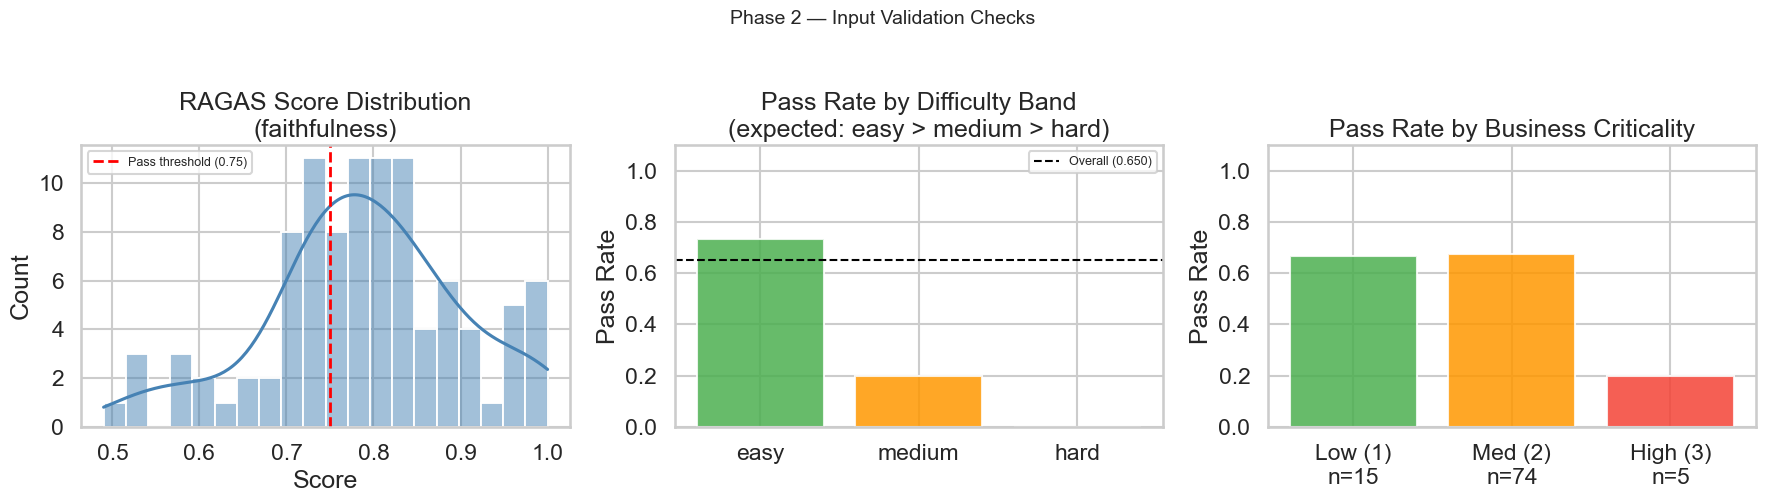

Saved: outputs/phase2/input_validation.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RAGAS score distribution with pass threshold
ax = axes[0]
sns.histplot(df["ragas_score"].dropna(), bins=20, kde=True, ax=ax, color="steelblue")
ax.axvline(PASS_THRESHOLD, color="red", linestyle="--", linewidth=2,
           label=f"Pass threshold ({PASS_THRESHOLD})")
ax.set_title(f"RAGAS Score Distribution\n({BINARIZATION_METRIC})")
ax.set_xlabel("Score")
ax.legend(fontsize=9)

# Plot 2: Pass/fail by difficulty band
ax = axes[1]
band_order = ["easy", "medium", "hard"]
band_pass  = df.groupby("difficulty_band")["pass_fail"].mean().reindex(band_order)
colors     = ["#4CAF50", "#FF9800", "#F44336"]
ax.bar(band_order, band_pass.values, color=colors, edgecolor="white", alpha=0.85)
ax.axhline(y=df["pass_fail"].mean(), color="black", linestyle="--",
           linewidth=1.5, label=f"Overall ({df['pass_fail'].mean():.3f})")
ax.set_title("Pass Rate by Difficulty Band\n(expected: easy > medium > hard)")
ax.set_ylabel("Pass Rate")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)

# Plot 3: Pass rate by criticality
ax = axes[2]
crit_pass = df.groupby("criticality_score")["pass_fail"].mean().dropna()
crit_colors = {1: "#4CAF50", 2: "#FF9800", 3: "#F44336"}
bars = ax.bar(
    [f"Low (1)\nn={df[df['criticality_score']==1]['pass_fail'].count()}",
     f"Med (2)\nn={df[df['criticality_score']==2]['pass_fail'].count()}",
     f"High (3)\nn={df[df['criticality_score']==3]['pass_fail'].count()}"],
    [crit_pass.get(1.0, 0), crit_pass.get(2.0, 0), crit_pass.get(3.0, 0)],
    color=["#4CAF50", "#FF9800", "#F44336"], edgecolor="white", alpha=0.85
)
ax.set_title("Pass Rate by Business Criticality")
ax.set_ylabel("Pass Rate")
ax.set_ylim(0, 1.1)

plt.suptitle("Phase 2 — Input Validation Checks", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "input_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/phase2/input_validation.png")

## Rating Setup

Questions are initialized using our Phase 1 composite difficulty scores.
This is the key connection between Phase 1 and Phase 2:

- Phase 1 (LLM-judged) difficulty → initializes question rating
- Phase 2 (empirical match outcomes) → updates question rating

After convergence, the empirical Glicko-2 rating should correlate
with the Phase 1 LLM-judged score — this is the validation.

In [7]:
def composite_to_question_rating(composite_score, base=BASE_RATING, spread=QUESTION_RATING_SPREAD):
    """
    Map composite difficulty (1.0–3.0) to initial Elo rating.
    1.0 (easy)   → base - spread  (e.g. 1400)
    2.0 (medium) → base           (e.g. 1500)
    3.0 (hard)   → base + spread  (e.g. 1600)
    """
    return base + (composite_score - 2.0) * spread

def initialize_ratings(df_input):
    model_ratings = {m: BASE_RATING for m in sorted(df_input["model_name"].unique())}

    q_df = (
        df_input[["question_id", "heuristic_difficulty"]]
        .drop_duplicates()
        .copy()
    )
    q_df["initial_rating"] = q_df["heuristic_difficulty"].apply(composite_to_question_rating)
    question_ratings = dict(zip(q_df["question_id"], q_df["initial_rating"]))

    return model_ratings, question_ratings

model_ratings_init, question_ratings_init = initialize_ratings(df)

print("Initial model ratings:")
for m, r in model_ratings_init.items():
    print(f"  {m}: {r:.1f}")

print(f"\nSample initial question ratings (first 5):")
for qid, r in list(question_ratings_init.items())[:5]:
    comp = df[df["question_id"]==qid]["heuristic_difficulty"].iloc[0]
    print(f"  {qid}: composite={comp:.2f} → initial_rating={r:.1f}")

Initial model ratings:
  RAG-System-v1: 1500.0

Sample initial question ratings (first 5):
  36f030c0-2cfe-4555-a271-e2207b65d9c5: composite=1.33 → initial_rating=1433.3
  fb84b1d8-9a22-4847-b0b1-1576d0a396ff: composite=2.33 → initial_rating=1533.3
  3a5ebf09-9fb8-44e8-98db-bae4cd4c329b: composite=1.67 → initial_rating=1466.7
  e4aa5613-8f28-44a6-ac2a-4e3186c624e0: composite=1.33 → initial_rating=1433.3
  33a6bf61-c5c9-4453-94f1-e6aa37a696ed: composite=1.00 → initial_rating=1400.0


## Elo Functions and Single Run

In [8]:
def expected_score(r_a, r_b):
    return 1 / (1 + 10 ** ((r_b - r_a) / 400))

def elo_update(r_model, r_question, outcome_model, k=ELO_K):
    exp_model    = expected_score(r_model, r_question)
    exp_question = expected_score(r_question, r_model)
    new_r_model    = r_model    + k * (outcome_model       - exp_model)
    new_r_question = r_question + k * ((1 - outcome_model) - exp_question)
    return new_r_model, new_r_question

def run_elo_once(df_input, k=ELO_K, seed=RANDOM_SEED):
    model_ratings, question_ratings = initialize_ratings(df_input)
    df_run = df_input.sample(frac=1, random_state=seed).reset_index(drop=True)
    for _, row in df_run.iterrows():
        m = row["model_name"]
        q = row["question_id"]
        outcome_model = row["pass_fail"]
        new_m, new_q = elo_update(model_ratings[m], question_ratings[q], outcome_model, k=k)
        model_ratings[m]    = new_m
        question_ratings[q] = new_q
    return model_ratings, question_ratings

# Single run to sanity check
mr1, qr1 = run_elo_once(df)
print("Single Elo run complete.")
print("Model ratings after one run:")
for m, r in sorted(mr1.items(), key=lambda x: -x[1]):
    print(f"  {m}: {r:.1f}")

Single Elo run complete.
Model ratings after one run:
  RAG-System-v1: 1552.6


## Stable Elo via Multiple Permutations

Single Elo runs are sensitive to update order.
We average over 100 random permutations for stable estimates.

In [9]:
def run_elo_permutations(df_input, n_permutations=N_PERMUTATIONS, k=ELO_K):
    model_runs    = []
    question_runs = []

    for seed in range(n_permutations):
        mr, qr = run_elo_once(df_input, k=k, seed=seed)
        model_runs.append(mr)
        question_runs.append(qr)

    model_runs_df    = pd.DataFrame(model_runs)
    question_runs_df = pd.DataFrame(question_runs)

    model_summary = pd.DataFrame({
        "model_name" : model_runs_df.columns,
        "ability_mean": model_runs_df.mean().values,
        "ability_sd"  : model_runs_df.std().values,
    }).sort_values("ability_mean", ascending=False)

    question_summary = pd.DataFrame({
        "question_id"   : question_runs_df.columns,
        "elo_difficulty_mean": question_runs_df.mean().values,
        "elo_difficulty_sd"  : question_runs_df.std().values,
    })

    question_summary = question_summary.merge(
        df_input[["question_id", "heuristic_difficulty", "composite_difficulty",
                  "difficulty_band", "criticality_score", "domain", "question"]].drop_duplicates(),
        on="question_id", how="left"
    )

    return model_summary, question_summary

print(f"Running {N_PERMUTATIONS} Elo permutations...")
model_summary, question_summary = run_elo_permutations(df)
print("Done.")

display(model_summary)
display(question_summary.sort_values("elo_difficulty_mean", ascending=False).head(10))

Running 100 Elo permutations...
Done.


,model_name,ability_mean,ability_sd
0,RAG-System-v1,1556.010531,29.790268


,question_id,elo_difficulty_mean,elo_difficulty_sd,heuristic_difficulty,composite_difficulty,difficulty_band,criticality_score,domain,question
86,b56698f8-1cba-4841-89c2-84e1f4ce9e95,1577.771907,1.092545,2.6667,2.6667,hard,1.0,Informational,How does the concept of entropy apply to econo...
74,fc696ad6-995b-4670-a69a-64f4a395caa3,1577.684015,1.213490,2.6667,2.6667,hard,2.0,Research and Development,In what ways can this methodological approach ...
26,2a50f720-593d-4fe8-b51f-7df971a083a8,1545.579460,1.212665,2.3333,2.3333,hard,2.0,Research and Development,How is an imbalance in representation identifi...
1,fb84b1d8-9a22-4847-b0b1-1576d0a396ff,1545.506197,1.234870,2.3333,2.3333,hard,2.0,Research and Development,How does the American framework differ from th...
5,9199173b-3ed1-4118-88cd-1713fc5fa8a7,1513.460273,1.049484,2.0000,2.0000,medium,NaN,FLAGGED,How do changes in effective microbial death ra...
52,13d172a6-bb0f-44ee-9b8a-09d3abab15ac,1513.399747,1.139037,2.0000,2.0000,medium,NaN,FLAGGED,How does dynamic similarity analysis (DSA) ext...
69,2ee8e18e-07f7-40a7-91b0-47d514f6913b,1513.370913,1.199609,2.0000,2.0000,medium,2.0,Research and Development,What role does information about other agents ...
51,39810050-7f41-49c5-8e93-a8c3dac96570,1513.360380,1.250270,2.0000,2.0000,medium,1.0,Onboarding and Training,How are usage examples generated for a package...
24,d72df1c0-5a86-440d-9332-8a855b2761ac,1513.359975,1.107235,2.0000,2.0000,medium,2.0,Research and Development,Why might one choose to use KDE-HPD over tradi...
72,44782556-505b-491a-8f8a-8f0dd44cbd28,1513.257997,1.256801,2.0000,2.0000,medium,2.0,Research and Development,Does the agent's controlled inventory process ...


## Elo Visualizations

/var/folders/m4/l4n6ymyn79v7lpnsyg85hmlh0000gn/T/ipykernel_60799/2763234962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_summary, x="ability_mean", y="model_name",


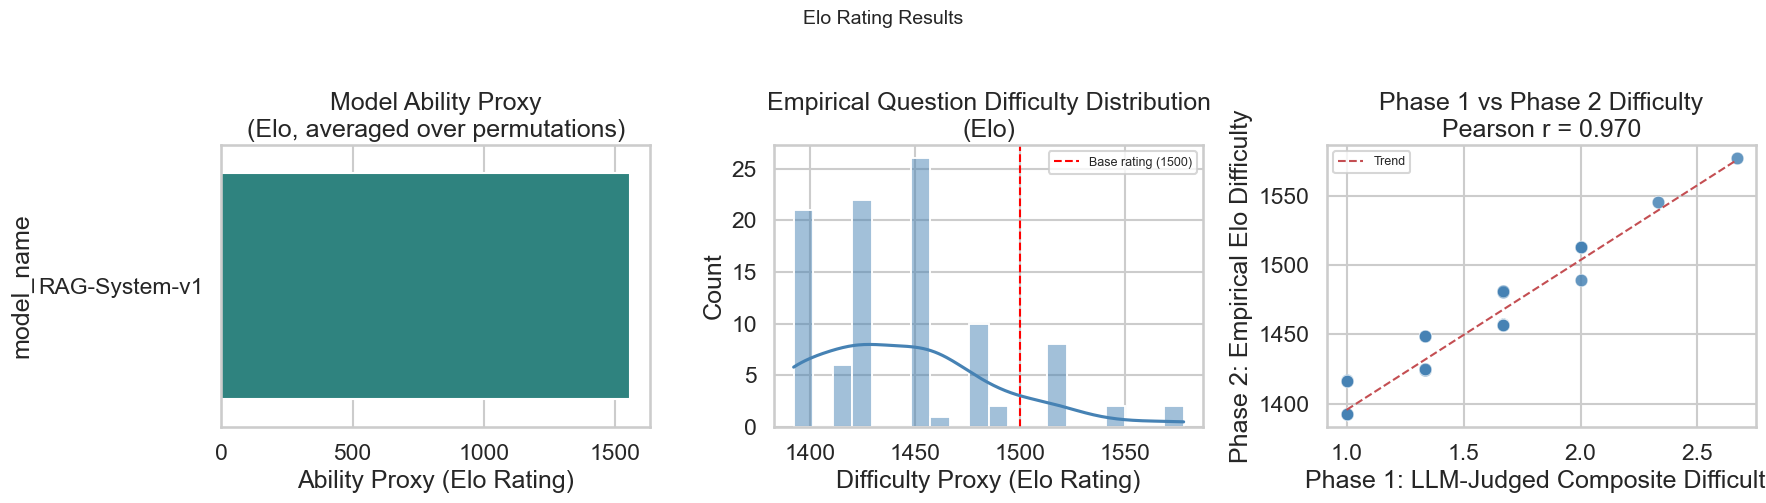

Saved: outputs/phase2/elo_results.png

KEY FINDING — Pearson correlation (Phase 1 vs Phase 2 difficulty): 0.970


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model ability
ax = axes[0]
sns.barplot(data=model_summary, x="ability_mean", y="model_name",
            palette="viridis", ax=ax)
ax.set_title("Model Ability Proxy\n(Elo, averaged over permutations)")
ax.set_xlabel("Ability Proxy (Elo Rating)")

# Question difficulty distribution
ax = axes[1]
sns.histplot(question_summary["elo_difficulty_mean"], bins=20, kde=True,
             ax=ax, color="steelblue")
ax.axvline(BASE_RATING, color="red", linestyle="--", linewidth=1.5,
           label=f"Base rating ({BASE_RATING})")
ax.set_title("Empirical Question Difficulty Distribution\n(Elo)")
ax.set_xlabel("Difficulty Proxy (Elo Rating)")
ax.legend(fontsize=9)

# Elo difficulty vs Phase 1 LLM-judged difficulty — the KEY validation plot
ax = axes[2]
plot_df = question_summary.dropna(subset=["composite_difficulty", "elo_difficulty_mean"])
ax.scatter(plot_df["composite_difficulty"], plot_df["elo_difficulty_mean"],
           alpha=0.6, color="steelblue", edgecolors="white", linewidths=0.5)
# Correlation
corr = plot_df["composite_difficulty"].corr(plot_df["elo_difficulty_mean"])
ax.set_title(f"Phase 1 vs Phase 2 Difficulty\nPearson r = {corr:.3f}")
ax.set_xlabel("Phase 1: LLM-Judged Composite Difficulty")
ax.set_ylabel("Phase 2: Empirical Elo Difficulty")

# Trend line
z = np.polyfit(plot_df["composite_difficulty"], plot_df["elo_difficulty_mean"], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df["composite_difficulty"].min(),
                      plot_df["composite_difficulty"].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=1.5, label="Trend")
ax.legend(fontsize=9)

plt.suptitle("Elo Rating Results", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "elo_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/phase2/elo_results.png")
print(f"\nKEY FINDING — Pearson correlation (Phase 1 vs Phase 2 difficulty): {corr:.3f}")

## Glicko-2

Glicko-2 adds explicit uncertainty (Rating Deviation) to each estimate.
- `rating` — the difficulty/ability estimate
- `rd` — Rating Deviation (lower = more certain)
- `volatility` — how stable the rating is expected to be

Questions with high RD are those where the system's behavior was inconsistent
— sometimes passing, sometimes failing. These are the most informative questions
for discrimination.

In [11]:
if USE_GLICKO2:
    try:
        from glicko2 import Player
        print("glicko2 loaded.")
    except ImportError:
        print("Install with: pip install glicko2")
        USE_GLICKO2 = False

glicko2 loaded.


In [12]:
if USE_GLICKO2:
    def make_player(rating=1500, rd=350, vol=0.06):
        p = Player()
        p.setRating(rating)
        p.setRd(rd)
        p.vol = vol
        return p

    # Models start at BASE_RATING with high uncertainty
    model_players = {
        m: make_player(BASE_RATING, 350, 0.06)
        for m in sorted(df["model_name"].unique())
    }

    # Questions initialized from Phase 1 composite difficulty
    q_meta = df[["question_id", "heuristic_difficulty"]].drop_duplicates().copy()
    question_players = {
        row["question_id"]: make_player(
            composite_to_question_rating(row["heuristic_difficulty"]),
            350, 0.06
        )
        for _, row in q_meta.iterrows()
    }

    print(f"Initialized {len(model_players)} model players")
    print(f"Initialized {len(question_players)} question players")
    print("\nSample question initial ratings:")
    for qid, p in list(question_players.items())[:5]:
        print(f"  {qid}: rating={p.getRating():.1f}, rd={p.getRd():.1f}")

Initialized 1 model players
Initialized 100 question players

Sample question initial ratings:
  36f030c0-2cfe-4555-a271-e2207b65d9c5: rating=1433.3, rd=350.0
  fb84b1d8-9a22-4847-b0b1-1576d0a396ff: rating=1533.3, rd=350.0
  3a5ebf09-9fb8-44e8-98db-bae4cd4c329b: rating=1466.7, rd=350.0
  e4aa5613-8f28-44a6-ac2a-4e3186c624e0: rating=1433.3, rd=350.0
  33a6bf61-c5c9-4453-94f1-e6aa37a696ed: rating=1400.0, rd=350.0


In [13]:
if USE_GLICKO2:
    # Build match lists for rating period update
    model_match_lists    = {m: [] for m in model_players}
    question_match_lists = {q: [] for q in question_players}

    for _, row in df.iterrows():
        m = row["model_name"]
        q = row["question_id"]
        if m not in model_players or q not in question_players:
            continue
        result_model    = row["pass_fail"]
        result_question = 1 - result_model

        model_match_lists[m].append((
            question_players[q].getRating(),
            question_players[q].getRd(),
            result_model
        ))
        question_match_lists[q].append((
            model_players[m].getRating(),
            model_players[m].getRd(),
            result_question
        ))

    # Apply Glicko-2 updates
    for m, matches in model_match_lists.items():
        if matches:
            model_players[m].update_player(
                [r for r, rd, s in matches],
                [rd for r, rd, s in matches],
                [s for r, rd, s in matches]
            )

    for q, matches in question_match_lists.items():
        if matches:
            question_players[q].update_player(
                [r for r, rd, s in matches],
                [rd for r, rd, s in matches],
                [s for r, rd, s in matches]
            )

    print("Glicko-2 updates applied.")

Glicko-2 updates applied.


In [14]:
if USE_GLICKO2:
    model_glicko_df = pd.DataFrame([{
        "model_name": m,
        "rating"    : p.getRating(),
        "rd"        : p.getRd(),
        "volatility": p.vol,
    } for m, p in model_players.items()]).sort_values("rating", ascending=False)

    question_glicko_df = pd.DataFrame([{
        "question_id": q,
        "glicko_rating"    : p.getRating(),
        "glicko_rd"        : p.getRd(),
        "glicko_volatility": p.vol,
    } for q, p in question_players.items()])

    question_glicko_df = question_glicko_df.merge(
        df[["question_id", "heuristic_difficulty", "composite_difficulty",
            "difficulty_band", "criticality_score", "question"]].drop_duplicates(),
        on="question_id", how="left"
    )

    display(model_glicko_df)
    display(question_glicko_df.sort_values("glicko_rating", ascending=False).head(10))

,model_name,rating,rd,volatility
0,RAG-System-v1,1601.298255,51.776871,0.060401


,question_id,glicko_rating,glicko_rd,glicko_volatility,heuristic_difficulty,composite_difficulty,difficulty_band,criticality_score,question
74,fc696ad6-995b-4670-a69a-64f4a395caa3,1708.980978,291.061562,0.06,2.6667,2.6667,hard,2.0,In what ways can this methodological approach ...
86,b56698f8-1cba-4841-89c2-84e1f4ce9e95,1708.980978,291.061562,0.06,2.6667,2.6667,hard,1.0,How does the concept of entropy apply to econo...
26,2a50f720-593d-4fe8-b51f-7df971a083a8,1685.432608,290.505551,0.06,2.3333,2.3333,hard,2.0,How is an imbalance in representation identifi...
1,fb84b1d8-9a22-4847-b0b1-1576d0a396ff,1685.432608,290.505551,0.06,2.3333,2.3333,hard,2.0,How does the American framework differ from th...
69,2ee8e18e-07f7-40a7-91b0-47d514f6913b,1662.310895,290.318965,0.06,2.0000,2.0000,medium,2.0,What role does information about other agents ...
80,aef516d0-ea1b-4873-b478-ca2b1b8e3b76,1662.310895,290.318965,0.06,2.0000,2.0000,medium,2.0,Can subjective beliefs replace objective stoch...
24,d72df1c0-5a86-440d-9332-8a855b2761ac,1662.310895,290.318965,0.06,2.0000,2.0000,medium,2.0,Why might one choose to use KDE-HPD over tradi...
32,97063f67-4ef5-41e9-8982-89f2235a6aec,1662.310895,290.318965,0.06,2.0000,2.0000,medium,3.0,Does misreporting by one client affect other c...
52,13d172a6-bb0f-44ee-9b8a-09d3abab15ac,1662.310895,290.318965,0.06,2.0000,2.0000,medium,NaN,How does dynamic similarity analysis (DSA) ext...
5,9199173b-3ed1-4118-88cd-1713fc5fa8a7,1662.310895,290.318965,0.06,2.0000,2.0000,medium,NaN,How do changes in effective microbial death ra...


/var/folders/m4/l4n6ymyn79v7lpnsyg85hmlh0000gn/T/ipykernel_60799/3342715666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_glicko_df, x="rating", y="model_name",


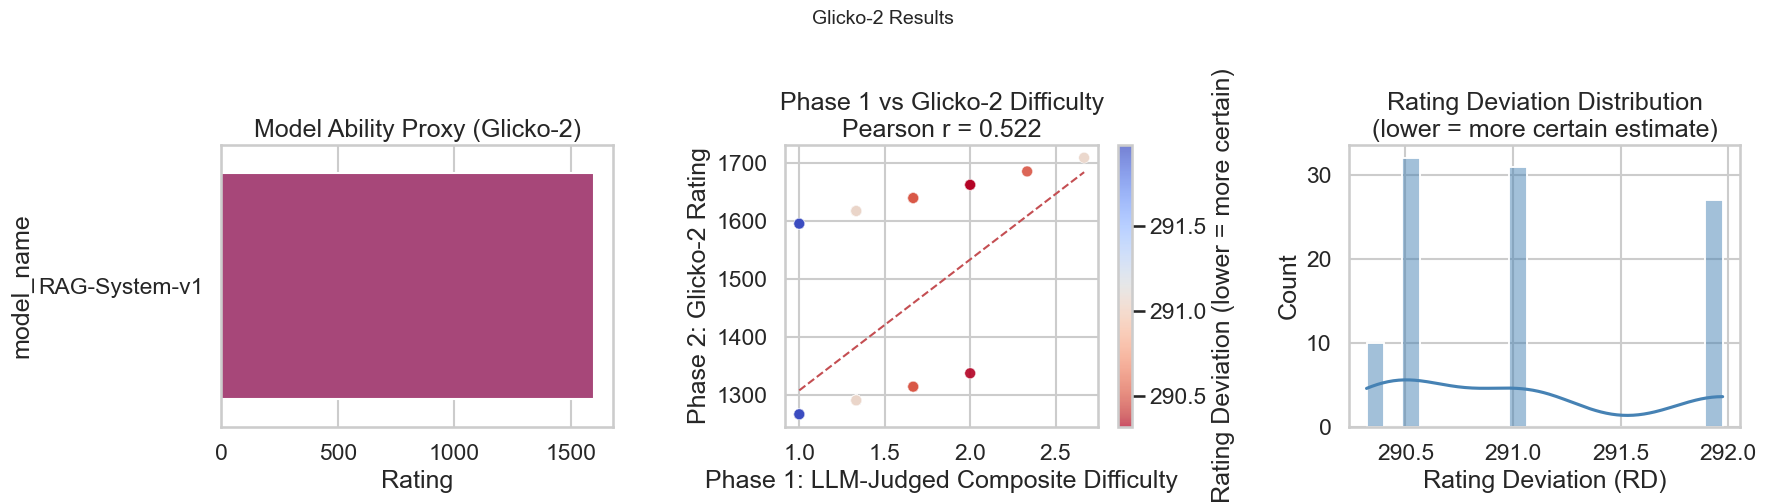

Saved: outputs/phase2/glicko2_results.png

KEY FINDING — Pearson r (Phase 1 vs Glicko-2): 0.522


In [15]:
if USE_GLICKO2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Model ratings
    ax = axes[0]
    sns.barplot(data=model_glicko_df, x="rating", y="model_name",
                palette="magma", ax=ax)
    ax.set_title("Model Ability Proxy (Glicko-2)")
    ax.set_xlabel("Rating")

    # Question rating vs Phase 1 difficulty — key validation
    ax = axes[1]
    plot_df = question_glicko_df.dropna(subset=["composite_difficulty", "glicko_rating"])
    scatter = ax.scatter(
        plot_df["composite_difficulty"],
        plot_df["glicko_rating"],
        c=plot_df["glicko_rd"],
        cmap="coolwarm_r",
        alpha=0.7, s=60,
        edgecolors="white", linewidths=0.4
    )
    plt.colorbar(scatter, ax=ax, label="Rating Deviation (lower = more certain)")
    corr_g = plot_df["composite_difficulty"].corr(plot_df["glicko_rating"])
    z = np.polyfit(plot_df["composite_difficulty"], plot_df["glicko_rating"], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(plot_df["composite_difficulty"].min(),
                          plot_df["composite_difficulty"].max(), 100)
    ax.plot(x_line, p_line(x_line), "r--", linewidth=1.5)
    ax.set_title(f"Phase 1 vs Glicko-2 Difficulty\nPearson r = {corr_g:.3f}")
    ax.set_xlabel("Phase 1: LLM-Judged Composite Difficulty")
    ax.set_ylabel("Phase 2: Glicko-2 Rating")

    # Rating deviation distribution
    ax = axes[2]
    sns.histplot(question_glicko_df["glicko_rd"], bins=20, kde=True,
                 ax=ax, color="steelblue")
    ax.set_title("Rating Deviation Distribution\n(lower = more certain estimate)")
    ax.set_xlabel("Rating Deviation (RD)")

    plt.suptitle("Glicko-2 Results", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "glicko2_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: outputs/phase2/glicko2_results.png")
    print(f"\nKEY FINDING — Pearson r (Phase 1 vs Glicko-2): {corr_g:.3f}")

## Final Unified Output

Merge everything into one per-question unified table:
- Phase 1 LLM-judged difficulty (all three dimensions)
- Phase 1 business criticality
- Phase 1 RAGAS scores
- Phase 2 Elo difficulty proxy
- Phase 2 Glicko-2 rating + uncertainty

In [16]:
# Build unified per-question table
unified = question_summary[["question_id", "question", "composite_difficulty",
                              "difficulty_band", "elo_difficulty_mean",
                              "elo_difficulty_sd", "criticality_score", "domain"]].copy()

if USE_GLICKO2:
    unified = unified.merge(
        question_glicko_df[["question_id", "glicko_rating", "glicko_rd", "glicko_volatility"]],
        on="question_id", how="left"
    )

# Add RAGAS scores
ragas_for_merge = ragas_df[["question_id", "faithfulness", "answer_relevance",
                              "context_recall", "composite_ragas"]].copy()
unified = unified.merge(ragas_for_merge, on="question_id", how="left")

# Sort by Glicko rating (empirical difficulty) descending
sort_col = "glicko_rating" if USE_GLICKO2 else "elo_difficulty_mean"
unified  = unified.sort_values(sort_col, ascending=False).reset_index(drop=True)

print(f"Unified table shape: {unified.shape}")
display(unified.head(15))

# Save
unified.to_csv(OUTPUT_DIR / "unified_question_scores.csv", index=False)
unified.to_json(OUTPUT_DIR / "unified_question_scores.json", orient="records", indent=2)
print(f"\nSaved: outputs/phase2/unified_question_scores.csv")
print(f"Saved: outputs/phase2/unified_question_scores.json")

Unified table shape: (100, 15)


,question_id,question,composite_difficulty,difficulty_band,elo_difficulty_mean,elo_difficulty_sd,criticality_score,domain,glicko_rating,glicko_rd,glicko_volatility,faithfulness,answer_relevance,context_recall,composite_ragas
0,fc696ad6-995b-4670-a69a-64f4a395caa3,In what ways can this methodological approach ...,2.6667,hard,1577.684015,1.213490,2.0,Research and Development,1708.980978,291.061562,0.06,0.5365,0.4382,0.4545,0.4764
1,b56698f8-1cba-4841-89c2-84e1f4ce9e95,How does the concept of entropy apply to econo...,2.6667,hard,1577.771907,1.092545,1.0,Informational,1708.980978,291.061562,0.06,0.4899,0.3975,0.4019,0.4298
2,2a50f720-593d-4fe8-b51f-7df971a083a8,How is an imbalance in representation identifi...,2.3333,hard,1545.579460,1.212665,2.0,Research and Development,1685.432608,290.505551,0.06,0.6038,0.5467,0.5131,0.5545
3,fb84b1d8-9a22-4847-b0b1-1576d0a396ff,How does the American framework differ from th...,2.3333,hard,1545.506197,1.234870,2.0,Research and Development,1685.432608,290.505551,0.06,0.6511,0.3169,0.2317,0.3999
4,2ee8e18e-07f7-40a7-91b0-47d514f6913b,What role does information about other agents ...,2.0000,medium,1513.370913,1.199609,2.0,Research and Development,1662.310895,290.318965,0.06,0.5337,0.6434,0.5866,0.5879
5,aef516d0-ea1b-4873-b478-ca2b1b8e3b76,Can subjective beliefs replace objective stoch...,2.0000,medium,1513.138364,1.182646,2.0,Research and Development,1662.310895,290.318965,0.06,0.5748,0.7296,0.4015,0.5686
6,d72df1c0-5a86-440d-9332-8a855b2761ac,Why might one choose to use KDE-HPD over tradi...,2.0000,medium,1513.359975,1.107235,2.0,Research and Development,1662.310895,290.318965,0.06,0.5697,0.7947,0.6485,0.6710
7,97063f67-4ef5-41e9-8982-89f2235a6aec,Does misreporting by one client affect other c...,2.0000,medium,1513.239596,1.227925,3.0,Compliance and Regulatory,1662.310895,290.318965,0.06,0.5213,0.6303,0.6820,0.6112
8,13d172a6-bb0f-44ee-9b8a-09d3abab15ac,How does dynamic similarity analysis (DSA) ext...,2.0000,medium,1513.399747,1.139037,NaN,FLAGGED,1662.310895,290.318965,0.06,0.6956,0.8481,0.5651,0.7029
9,9199173b-3ed1-4118-88cd-1713fc5fa8a7,How do changes in effective microbial death ra...,2.0000,medium,1513.460273,1.049484,NaN,FLAGGED,1662.310895,290.318965,0.06,0.5769,0.7806,0.5053,0.6209



Saved: outputs/phase2/unified_question_scores.csv
Saved: outputs/phase2/unified_question_scores.json


In [17]:
print("=" * 60)
print("  PHASE 2 SUMMARY — KEY VALIDATION FINDINGS")
print("=" * 60)

elo_corr = question_summary["composite_difficulty"].corr(question_summary["elo_difficulty_mean"])
print(f"\nElo validation:")
print(f"  Pearson r (Phase 1 LLM-judged vs Elo difficulty): {elo_corr:.3f}")
if abs(elo_corr) > 0.3:
    print(f"  ✅ Moderate-strong correlation — Phase 1 difficulty taxonomy")
    print(f"     is predictively valid (correlates with empirical outcomes)")
else:
    print(f"  ⚠️  Weak correlation — Phase 1 scores may not predict")
    print(f"     empirical RAG difficulty. Consider refining taxonomy.")

if USE_GLICKO2:
    glicko_corr = question_glicko_df["composite_difficulty"].corr(question_glicko_df["glicko_rating"])
    print(f"\nGlicko-2 validation:")
    print(f"  Pearson r (Phase 1 LLM-judged vs Glicko-2 rating): {glicko_corr:.3f}")
    mean_rd = question_glicko_df["glicko_rd"].mean()
    print(f"  Mean RD across questions: {mean_rd:.1f}")
    print(f"  (Lower RD = more certain empirical estimates)")

print(f"\nOutputs saved to: outputs/phase2/")
print(f"  unified_question_scores.csv")
print(f"  unified_question_scores.json")
print(f"  elo_results.png")
print(f"  glicko2_results.png")
print(f"  input_validation.png")
print("=" * 60)

  PHASE 2 SUMMARY — KEY VALIDATION FINDINGS

Elo validation:
  Pearson r (Phase 1 LLM-judged vs Elo difficulty): 0.970
  ✅ Moderate-strong correlation — Phase 1 difficulty taxonomy
     is predictively valid (correlates with empirical outcomes)

Glicko-2 validation:
  Pearson r (Phase 1 LLM-judged vs Glicko-2 rating): 0.522
  Mean RD across questions: 291.1
  (Lower RD = more certain empirical estimates)

Outputs saved to: outputs/phase2/
  unified_question_scores.csv
  unified_question_scores.json
  elo_results.png
  glicko2_results.png
  input_validation.png
